In [2]:
import sys
sys.path.append(".")

from utils import load_prices, compute_returns, build_network
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Ready")

Ready


In [3]:
prices = load_prices(start="2019-01-01", end="2024-12-31")
returns = compute_returns(prices)

print(f"Prices shape: {prices.shape}")
print(f"Returns shape: {returns.shape}")

[*********************100%***********************]  55 of 55 completed


Prices shape: (2191, 55)
Returns shape: (2190, 55)


In [4]:
results = pd.read_csv("data/results.csv", index_col=0, parse_dates=True)

Equity curve

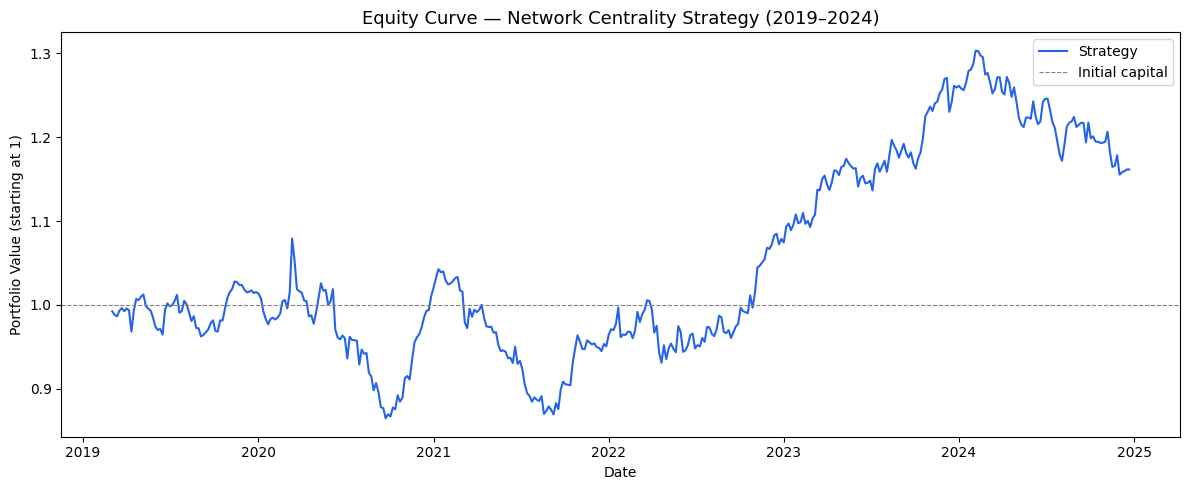

Final portfolio value: 1.1614


In [6]:
equity_curve = np.exp(results["strategy"].cumsum())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(equity_curve.index, equity_curve.values, color="#2563eb", linewidth=1.5, label="Strategy")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Initial capital")
ax.set_title("Equity Curve — Network Centrality Strategy (2019–2024)", fontsize=13)
ax.set_ylabel("Portfolio Value (starting at 1)")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend()
plt.tight_layout()
plt.savefig("equity_curve.png", dpi=150)
plt.show()

print(f"Final portfolio value: {equity_curve.iloc[-1]:.4f}")

Everything above the reference line at value 1.0 means profit.

The equity curve is the value of your portfolio over the period in consideration (here from 2019 to 2024)

In our case this total value is 1.1614, which means we would have made 16% profit over the whole period if we had adopted that strategy.

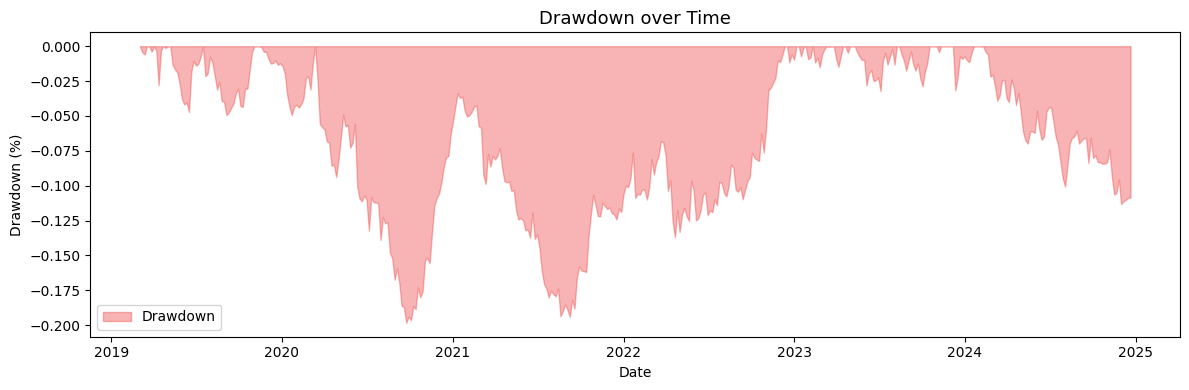

  STRATEGY PERFORMANCE SUMMARY
  Mean weekly return : 0.0004  (1.8% annualized)
  Weekly volatility  : 0.0119   (8.6% annualized)
  Annualized Sharpe  : 0.213
  Max drawdown       : -19.8%
  Total return       : 16.1%


In [7]:
# --- Performance Metrics ---

# Annualized Sharpe Ratio (weekly returns → annualize by sqrt(52))
weekly_mean = results["strategy"].mean()
weekly_std  = results["strategy"].std()
sharpe = (weekly_mean / weekly_std) * np.sqrt(52)

# Max Drawdown
rolling_max = equity_curve.cummax()          # highest equity value seen so far
drawdown    = (equity_curve - rolling_max) / rolling_max  # how far below peak we are
max_drawdown = drawdown.min()                # worst trough relative to peak

# Max Drawdown plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(drawdown.index, drawdown.values, 0, color="#ef4444", alpha=0.4, label="Drawdown")
ax.set_title("Drawdown over Time", fontsize=13)
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend()
plt.tight_layout()
plt.savefig("drawdown.png", dpi=150)
plt.show()

# Summary
print("=" * 40)
print("  STRATEGY PERFORMANCE SUMMARY")
print("=" * 40)
print(f"  Mean weekly return : {weekly_mean:.4f}  ({weekly_mean*52*100:.1f}% annualized)")
print(f"  Weekly volatility  : {weekly_std:.4f}   ({weekly_std*np.sqrt(52)*100:.1f}% annualized)")
print(f"  Annualized Sharpe  : {sharpe:.3f}")
print(f"  Max drawdown       : {max_drawdown*100:.1f}%")
print(f"  Total return       : {(equity_curve.iloc[-1]-1)*100:.1f}%")
print("=" * 40)

The Sharpe (0.213) is low, but the strategy is derived purely from network topology with no parameter optimization, so any positive signal is meaningful.

The Max drawdown is the worst drop of the equitiy curve across its entire history, it is the most painful moment for an investor in this strategy.

Notice here that in the computation of rolling_max, cummax() take the current point in time and look in the past what was the highest value of the equity curve. 

Note : Weekly volatility: 0.0119 × √52 = 0.0858 → 8.6%
Multiplied by √52, not 52, because volatility scales with the square root of time. This comes from the statistical properties of random processes — variance scales linearly with time, so standard deviation scales with √time

Interpretation

-   Total return +16.1% over 6 years — modest. That's roughly 2.5% per year, which barely beats a savings account. Raw return alone looks weak.
-   Annualized Sharpe 0.213 — weak but positive. The signal is real, it's just not strong enough on its own to be a standalone strategy. In practice it would be one input among many.
-   Max drawdown -19.8% — acceptable given the context. We never lost more than ~20% from peak to trough, which is in line with many long-only equity strategies during the same period that includes COVID (2020) and the 2022 rate hike selloff.
-   The ratio : volatility of 8.6% for only 2.1% annual return means we're taking on meaningful risk for a small reward. That's what the Sharpe of 0.21 is telling numerically.